In [1]:
import lightning as L
from pytorch_lightning.loggers import CSVLogger
import numpy as np
from torchvision import transforms
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint




In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data"
DATA_PATH

PosixPath('/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/data')

In [3]:
from src.model_training_pipeline import SiameseModel  
from src.datamodule import SignatureDataModule  
from src.random_seed_utils import seed_everything

In [4]:
seed_everything()

In [5]:
train_transforms = transforms.Compose([
        transforms.Resize((128, 128)),

        transforms.RandomRotation(5),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.02, 0.02),  
            scale=(0.95, 1.05),       
            shear=2                
        ),
        transforms.RandomHorizontalFlip(p=0.2),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])


val_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])



In [6]:
dm = SignatureDataModule(
    data_dir=DATA_PATH,
    batch_size=32,
    num_workers=4,
    positive_ratio=0.5,
    image_size=128,
    samples_per_epoch=10000,
    train_transformations=train_transforms,
    val_transformations=val_transforms,
    test_transformations=test_transforms
)

# Setup datasets (fit stage)
dm.setup(stage="fit")

In [7]:
print(
    "Train:", len(dm.train_dataset),
    "Val:", len(dm.val_dataset),
    "Test:", len(getattr(dm, "test_dataset", []))
)

Train: 10000 Val: 10000 Test: 0


In [8]:
len(dm.train_dataloader()), len(dm.val_dataloader())

(312, 79)

In [9]:
train_loader = dm.train_dataloader()
val_loader   = dm.val_dataloader()

print("Train batches per epoch:", len(train_loader))
print("Val batches per epoch:", len(val_loader))

Train batches per epoch: 312
Val batches per epoch: 79



===== TRAIN SANITY CHECK =====
img1 shape: torch.Size([32, 1, 128, 128])
img2 shape: torch.Size([32, 1, 128, 128])
labels shape: torch.Size([32])
dtype: torch.float32
unique labels: tensor([0., 1.])
train sanity passed.


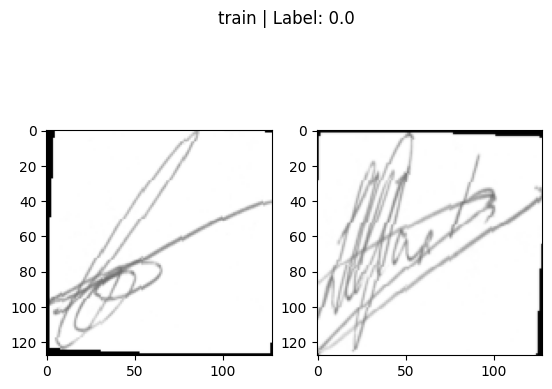

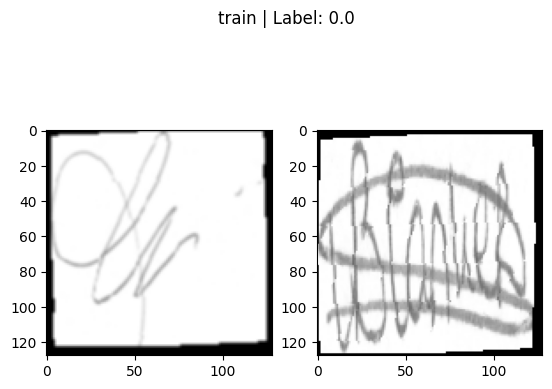

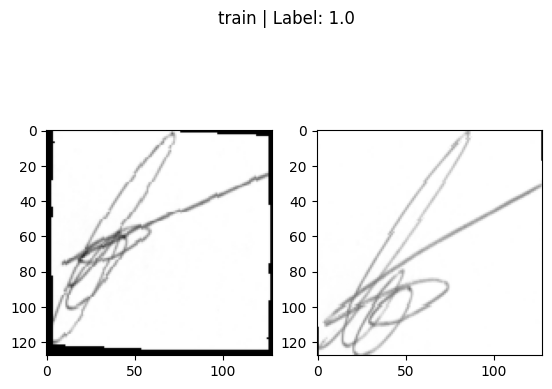


===== VAL SANITY CHECK =====
img1 shape: torch.Size([32, 1, 128, 128])
img2 shape: torch.Size([32, 1, 128, 128])
labels shape: torch.Size([32])
dtype: torch.float32
unique labels: tensor([0., 1.])
val sanity passed.


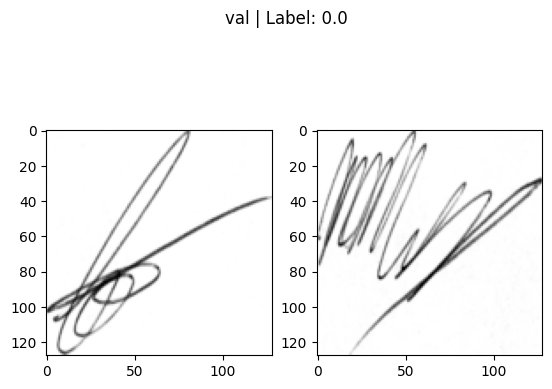

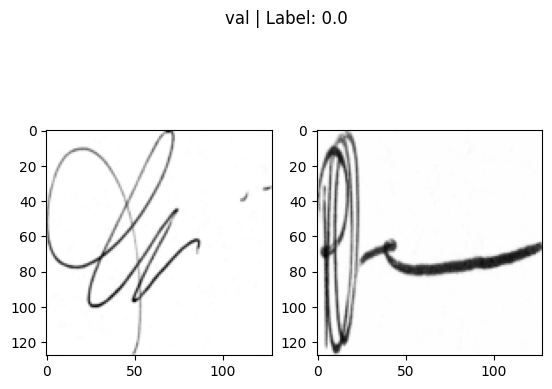

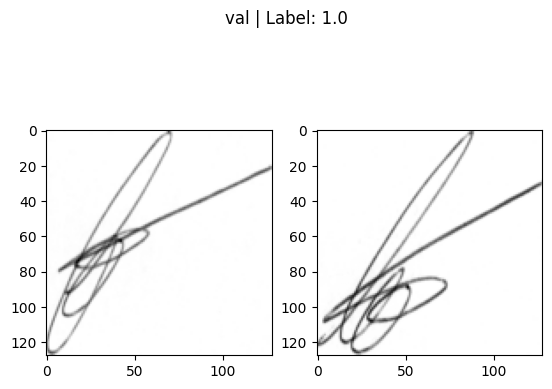

In [10]:
from src.dataloader_utils import sanity_check_loader


sanity_check_loader(loader=dm.train_dataloader(),split_name="train")
sanity_check_loader(loader=dm.val_dataloader(),split_name="val")

In [11]:
model = SiameseModel(
    embedding_dim=128,
    lr=1e-3,
    margin=1.0
)

In [12]:
logger = CSVLogger("train_logs", name="siamese_signature")

In [13]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",      # metric to monitor
    patience=5,              # stop if no improvement after 5 epochs
    mode="min",              # we want to minimize val_loss
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",      # metric to monitor
    dirpath="checkpoints",   # folder to save checkpoints
    filename="siamese-{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,            # save only the best model
    mode="min",
    verbose=True
)

In [14]:
trainer = L.Trainer(
    max_epochs=60,
    accelerator="auto",
    devices=1,
    logger=logger,
    log_every_n_steps=1,
    callbacks=[early_stop_callback, checkpoint_callback]
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [15]:
# trainer.fit(model, datamodule=dm)

### Stopped forcefully at 36 epochs (45 mins of training)

In [16]:
checkpoint_path = "train_logs/siamese_signature/version_0/checkpoints/epoch=36-step=11544.ckpt"
model = SiameseModel.load_from_checkpoint(checkpoint_path)
model.eval()

SiameseModel(
  (backbone): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [17]:
from src.train_metrics_utils import compute_best_threshold,plot_roc,call_plot_distribution,load_lightning_metrics,plot_train_stats

In [18]:
best_threshold, fpr, tpr, thresholds, auc_score = compute_best_threshold(model=model, val_loader=val_loader)


Best threshold: -0.5425889492034912
Mean FPR: 0.30694939759036144
Mean TPR: 0.6924851405622491
AUC: 0.84970624


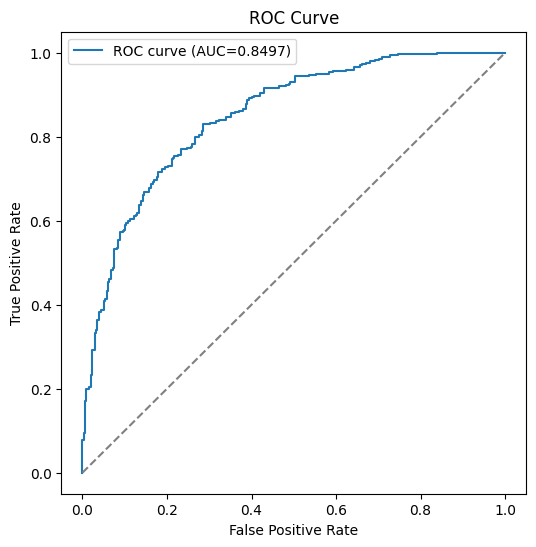

In [19]:
print("Best threshold:", best_threshold)
print("Mean FPR:", fpr.mean())
print("Mean TPR:", tpr.mean())
print("AUC:", auc_score)
plot_roc(fpr, tpr, auc_score)

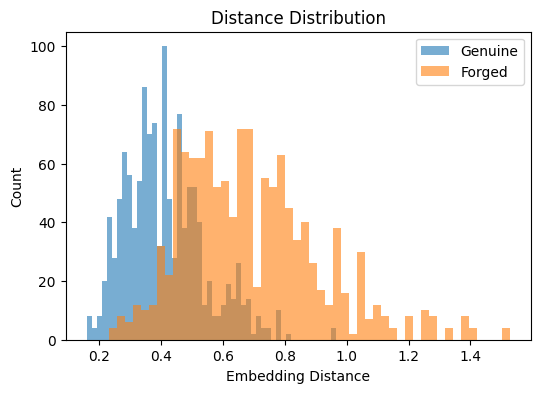

In [20]:
call_plot_distribution(val_loader=val_loader,model=model)

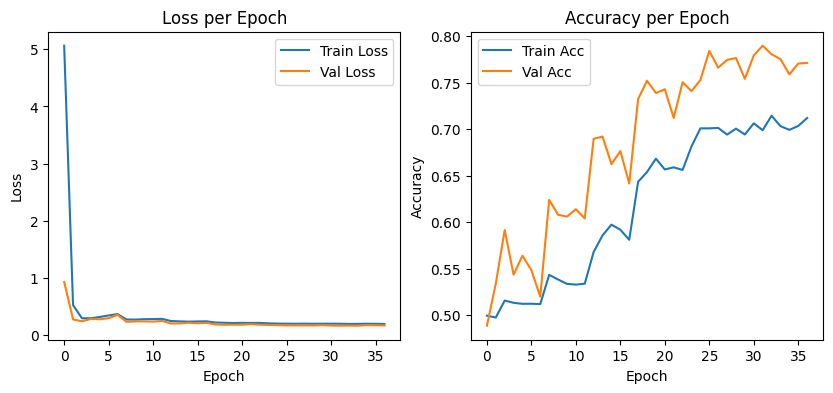

In [21]:
metrics = load_lightning_metrics(logger_csv_path="train_logs/siamese_signature/version_0/metrics.csv")
plot_train_stats(metrics)

In [22]:
dm.setup(stage="test") 

In [23]:
test_loader = dm.test_dataloader()
len(dm.test_dataset)

10000

In [24]:
len(test_loader)

313

In [25]:
model.test_threshold = - best_threshold
trainer.test(model, datamodule=dm)



💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

Total samples: 10000

[{}]

In [26]:
preds = model.test_preds
labels = model.test_labels
distances = model.test_distances

In [27]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(labels.numpy(), preds.numpy())
print(acc)

0.5996


In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

cm = confusion_matrix(labels, preds)
cm_df = pd.DataFrame(cm, index=["Actual Forged", "Actual Genuine"],
                     columns=["Pred Forged", "Pred Genuine"])
print(cm_df)

print("\nClassification Report:\n")
print(classification_report(labels, preds, target_names=["Forged", "Genuine"]))

                Pred Forged  Pred Genuine
Actual Forged          1046          3944
Actual Genuine           60          4950

Classification Report:

              precision    recall  f1-score   support

      Forged       0.95      0.21      0.34      4990
     Genuine       0.56      0.99      0.71      5010

    accuracy                           0.60     10000
   macro avg       0.75      0.60      0.53     10000
weighted avg       0.75      0.60      0.53     10000



### Siamese Training Log Analysis (Summary)

| Aspect                   | Evidence from Logs                 | Inference                              | Potential Impact                           |
| ------------------------ | ---------------------------------- | -------------------------------------- | ------------------------------------------ |
| **Model learning**       | Train acc: ~0.50 → ~0.71           | Model is learning embeddings gradually | Training is stable but slow                |
| **Generalization**       | Val acc: ~0.49 → ~0.79             | Validation improves steadily           | No strong overfitting                      |
| **Embedding separation** | Val AUC: 0.67 → **0.87**           | Embedding space becoming separable     | Model learning meaningful similarity       |
| **Loss trend**           | Val loss: 0.92 → ~0.16             | Contrastive learning converging        | Optimization working correctly             |
| **LR schedule**          | 1e-3 → 3.1e-5                      | LR decayed many times                  | Late training progress slowed              |
| **Training plateau**     | After epoch ~25 improvements small | Model near convergence                 | Further training gives diminishing returns |
| **Thresholding**         | AUC >> accuracy in some epochs     | Distance threshold not optimal         | Accuracy underestimates model quality      |
| **Backbone freezing**    | Train acc growth slow              | Features limited by frozen ResNet      | Representation learning restricted         |
| **Pair difficulty**      | Early instability in val_acc       | Some hard pairs or noisy forgeries     | Dataset likely heterogeneous               |


### Quick Wins (Top Improvements)

| Priority | Change                                                              | Expected Benefit                        |
| -------- | ------------------------------------------------------------------- | --------------------------------------- |
| **1**    | **Unfreeze last ResNet block (`layer4`)**                           | Better feature adaptation to signatures |
| **2**    | **Optimize decision threshold using ROC/EER instead of `margin/2`** | Immediate accuracy improvement          |


### Secondary Improvements

| Area                    | Suggested Change                                   | Reason                           |
| ----------------------- | -------------------------------------------------- | -------------------------------- |
| Learning rate           | Start with **1e-4 instead of 1e-3**                | More stable contrastive training |
| Data transforms         | Add **random affine / stroke thickness variation** | Improves forgery robustness      |
| Embedding normalization | Apply **L2 normalization on embeddings**           | Stabilizes distance metric       |
| Pair sampling           | Balance hard negatives                             | Improves decision boundary       |


### Overall Assessment

| Category           | Status                                 |
| ------------------ | -------------------------------------- |
| Training stability | Good                                   |
| Overfitting        | Not observed                           |
| Embedding quality  | Strong (AUC ~0.87)                     |
| Optimization       | Mostly converged                       |
| Largest bottleneck | Frozen backbone + suboptimal threshold |
